In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress 
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle
from statsmodels.graphics.tsaplots import plot_acf


In [11]:
salinity = xr.open_dataset('../salinity_ts_0.25.nc')['sos_abs']
amplitude = xr.open_dataset('../amplitude_ts_0.25.nc')['tos_con']
salinity['time_counter'] = salinity['time_counter'].dt.year

In [ ]:
## Salinity Residuals - Compute Shapiro - Wilk at each grid point 

nyears, nj, ni = salinity.shape
sw = np.full((nj, ni), np.nan, dtype=float)


for j in range (nj):
    for i in range (ni):
        point = salinity.isel(j=j, i=i)
        if np.isnan(point).all():
            continue
        slope, intercept, r_value, p_value, std_err = linregress(point['time_counter'], point.values)
        y_hat = intercept + slope * point['time_counter']
        residuals = point.values - y_hat
        sw[j, i] = shapiro(residuals).pvalue
    print(j)


In [7]:
sw_vals = sw[~np.isnan(sw)]



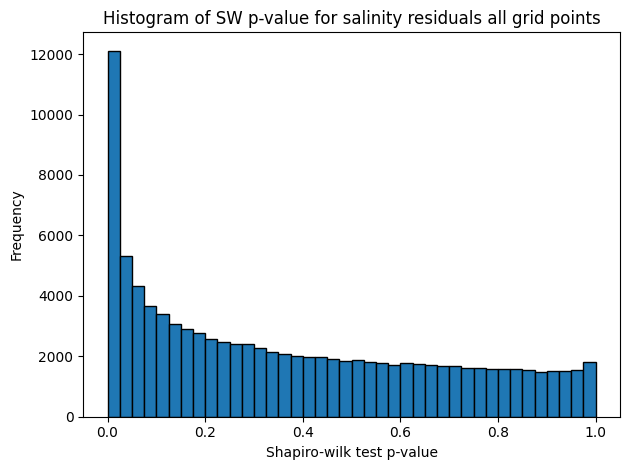

In [8]:
fig, ax = plt.subplots()

ax.hist(sw_vals, bins=40, edgecolor='black')
ax.set_xlabel("Shapiro-wilk test p-value")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of SW p-value for salinity residuals all grid points")

plt.tight_layout()
plt.show()

In [20]:
pval_da = xr.DataArray(data = sw, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for Sahpiro Wilk test of Salinity Residuals'})

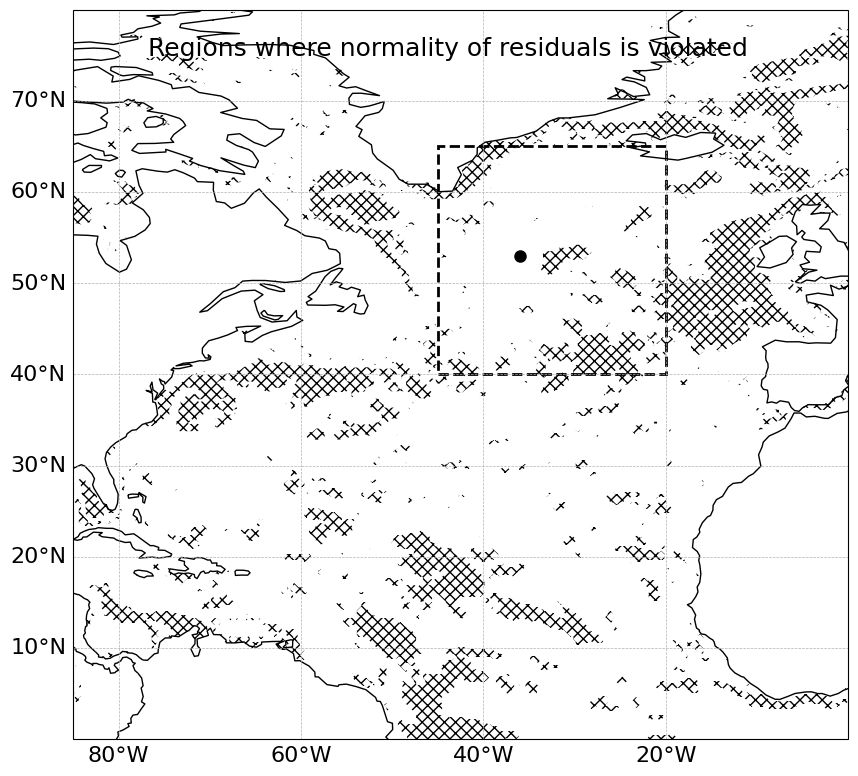

In [22]:
## Hatched Plot 

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('Regions where normality of residuals is violated',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())


In [ ]:
## Amplitude Residuals - Compute Shapiro - Wilk at each grid point 

nyears, nj, ni = amplitude.shape
sw2 = np.full((nj, ni), np.nan, dtype=float)


for j in range (nj):
    for i in range (ni):
        point = amplitude.isel(j=j, i=i)
        if np.isnan(point).all():
            continue
        slope, intercept, r_value, p_value, std_err = linregress(point['year'], point.values)
        y_hat = intercept + slope * point['year']
        residuals = point.values - y_hat
        sw2[j, i] = shapiro(residuals).pvalue
    print(j)

sw2_vals = sw2[~np.isnan(sw2)]


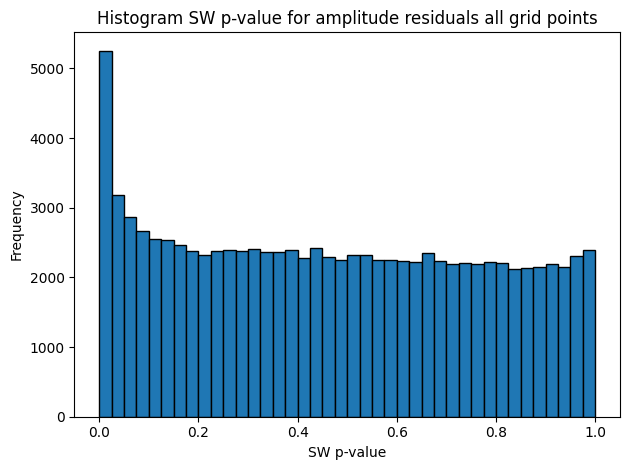

In [23]:
fig, ax = plt.subplots()

ax.hist(sw2_vals, bins=40, edgecolor='black')
ax.set_xlabel("SW p-value")
ax.set_ylabel("Frequency")
ax.set_title("Histogram SW p-value for amplitude residuals all grid points")

plt.tight_layout()
plt.show()

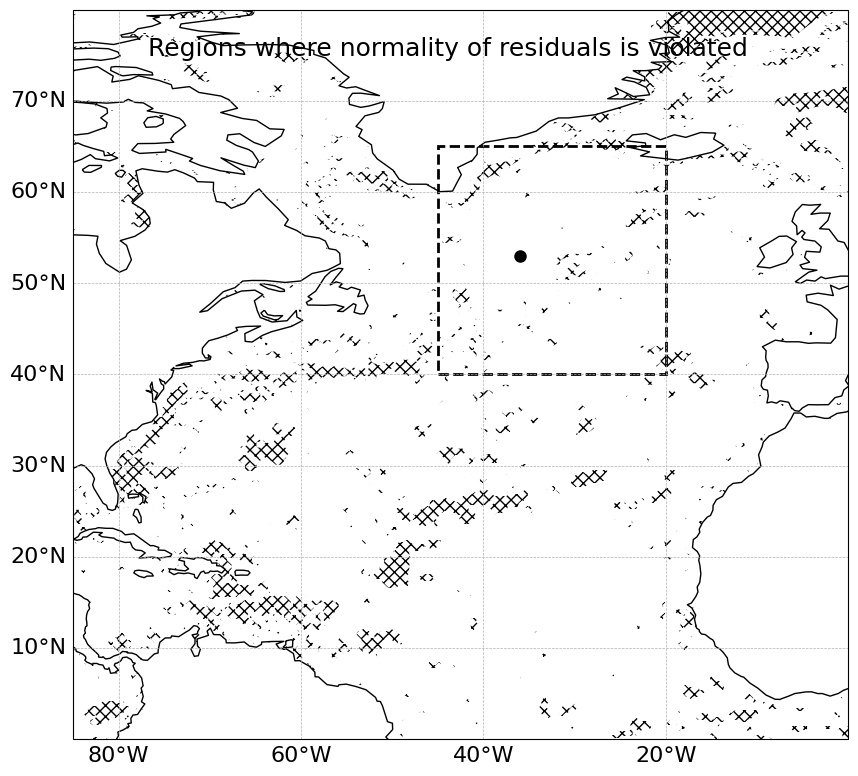

In [24]:
## Hatched Plot 
pval_da = xr.DataArray(data = sw2, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for Sahpiro Wilk test of Amplitude Residuals'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
fig.suptitle('Regions where normality of residuals is violated',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())


In [ ]:
## Regression Residuals - Compute Shapiro - Wilk at each grid point 

nyears, nj, ni = salinity.shape
sw3 = np.full((nj, ni), np.nan, dtype=float)


for j in range (nj):
    for i in range (ni):
        sal_ts = salinity.isel(j=j, i=i).values
        amp_ts = amplitude.isel(j=j, i=i).values
        if np.isnan(point).all():
            continue
        slope, intercept, r_value, p_value, std_err = linregress(sal_ts, amp_ts) 
        y_hat = intercept + slope * sal_ts
        residuals = amp_ts - y_hat
        sw3[j, i] = shapiro(residuals).pvalue
    print(j)
